### The dataset used for this project is a customer churn dataset from a public source. 
### It contains customer details, services, and subscription information. 
### Initial data checking was done using Python.

In [1]:
import pandas as pd 

#Load dataset
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [3]:
# Information about dataset
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Stats Summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Checking missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges']

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [7]:
# Checking and changing data type of TotalCharge 
df["TotalCharges"].dtypes

dtype('O')

In [8]:
# Changing it to Numeric and using coerce to convert the Null values to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df["TotalCharges"].dtypes

dtype('float64')

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
# Dropping null values cause the values are minimal and it wont affect analysis
df = df.dropna()

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

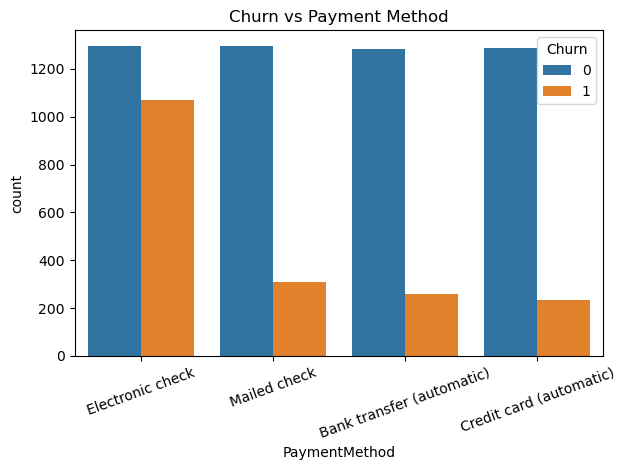

In [58]:
# Payment Method vs Churn

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Churn vs Payment Method")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/churn_vs_paymentmethod.png")
plt.show()

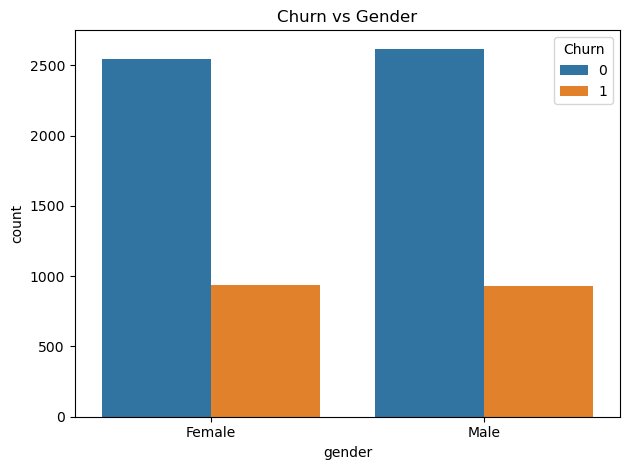

In [60]:
# Gender vs Churn

plt.figure()
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Churn vs Gender")
plt.tight_layout()
plt.savefig("../outputs/churn_vs_gender.png")
plt.show()

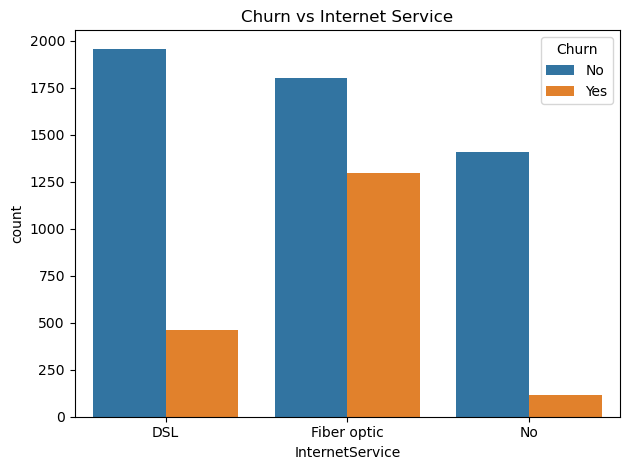

In [14]:
# Internet Service vs Churn

plt.figure()
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn vs Internet Service")
plt.tight_layout()
plt.savefig("../outputs/churn_vs_internetservice.png")
plt.show()

### Graph 1 — Churn Distribution

This graph shows how many customers have churned and how many have not.

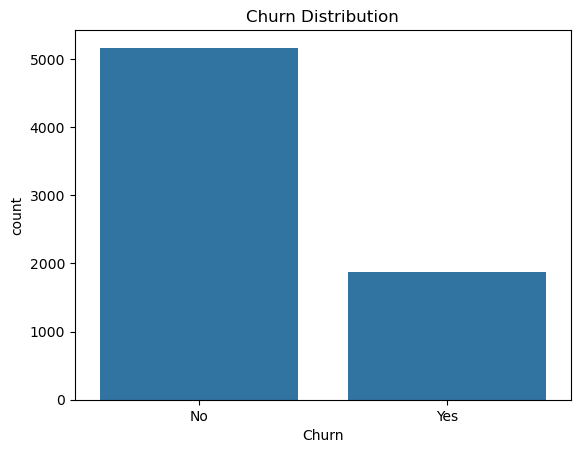

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.savefig("../outputs/churn_distribution.png")
plt.show()



#### Insights: 
- This graph Distribution of Number of Customers who have Churned and No fo those Customers who have not Churned. 
- Most customers have Not Churned.
- However the the No of Churning Customer is lesser but still noticeable.

### Graph 2 —  Churn by Contract Type

This graph shows how churn varies based on different contract types.

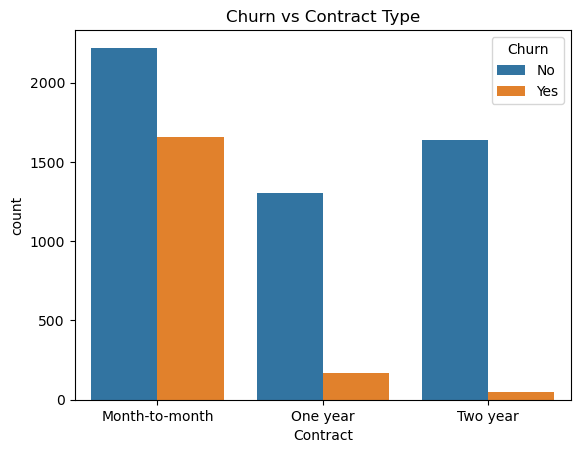

In [16]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn vs Contract Type")
plt.savefig("../outputs/churn_vs_contract.png")
plt.show()

In [17]:
churn_rate = pd.crosstab(df["Contract"], df["Churn"], normalize="index")*100

In [18]:
churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


#### Insight:
Used CountPlot
- This analysis shows that customers who have Month-to-month contract have the Highest churn compared to One Year contract and Two Year contract.
- This show that customer with longer contract stays and churn slower compared to shorter contract leaves early.
- This also suggest that longer the contract longer the commitment and also helps in customer retention.

### GRAPH 3 — Monthly Charges vs Churn

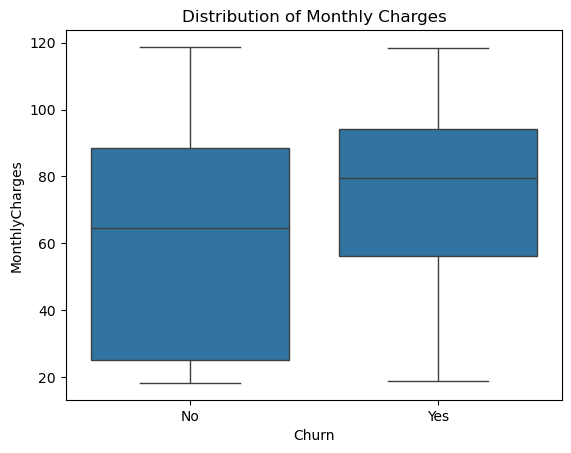

In [19]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Distribution of Monthly Charges")
plt.savefig("../outputs/churn_vs_monthlycharges.png")
plt.show()

#### Insights:
Used BoxPlot to show distribution 
- It analysis that the Customer Who Churned paid more montly charges than the Customer who are not Churned.
- This might indicate that higher price may be a problem for customer churn.

### GRAPH 4 — Churn Rate by Tenure Group

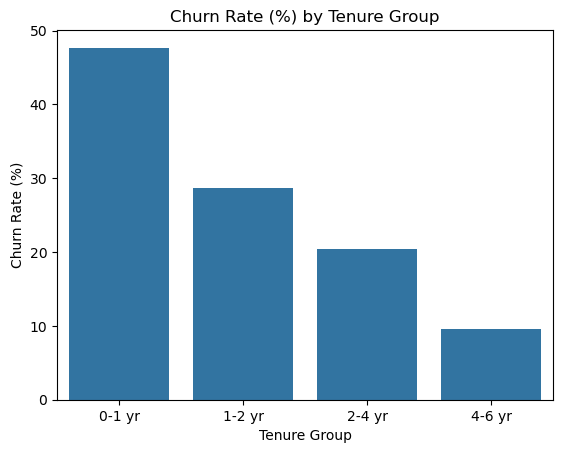

In [20]:
# create groups
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 yr', '1-2 yr', '2-4 yr', '4-6 yr']
)

# compute churn rate %
rate = (
    pd.crosstab(df['tenure_group'], df['Churn'], normalize='index')
    .mul(100)
    .reset_index()
)

# keep only churn = Yes
rate_yes = rate[['tenure_group', 'Yes']].rename(columns={'Yes': 'ChurnRate'})

# plot
sns.barplot(data=rate_yes, x='tenure_group', y='ChurnRate')
plt.title("Churn Rate (%) by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Group")
plt.savefig("../outputs/churn_rate_tenure_group.png")
plt.show()

#### Insight:
Used BarPlot
- It analysis that where the Customer has lower tenure (0-1Year) the churn rate is higher and as the tenure increases the churn rate in lower.
- This suggests that customer that stayed longer are less likely to leave, indicating newer customer churn early

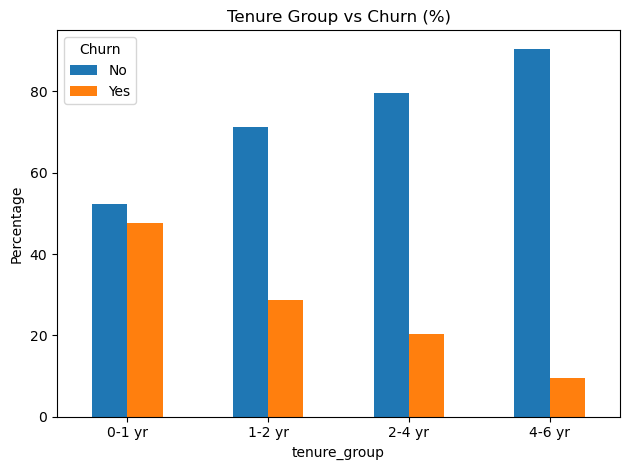

In [21]:
# Tenure vs Churn

tenure_churn = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100

tenure_churn.plot(kind='bar')
plt.title("Tenure Group vs Churn (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/tenure_vs_churn.png")
plt.show()

### CUSTOMER SEGMENTATION

#### Create Risk-Based Segments
- High Risk → likely to churn
- Medium Risk
- Low Risk → loyal

In [22]:
def segment_customer(row):
    if row['Contract'] == 'Month-to-month' and row['tenure'] < 12 and row['MonthlyCharges'] > 70:
        return 'High Risk'
    elif row['tenure'] < 24:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['RiskSegment'] = df.apply(segment_customer, axis=1)

df['RiskSegment'].value_counts()

RiskSegment
Low Risk       3927
Medium Risk    2291
High Risk       814
Name: count, dtype: int64

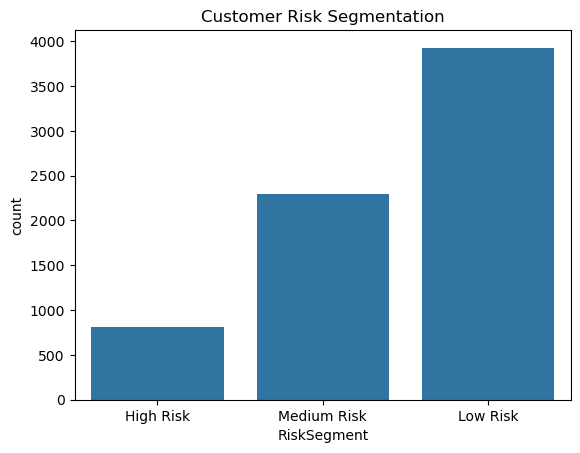

In [23]:
sns.countplot(x='RiskSegment', data=df, order=['High Risk','Medium Risk','Low Risk'])
plt.title("Customer Risk Segmentation")
plt.savefig("../outputs/risk_segmentation.png")
plt.show()

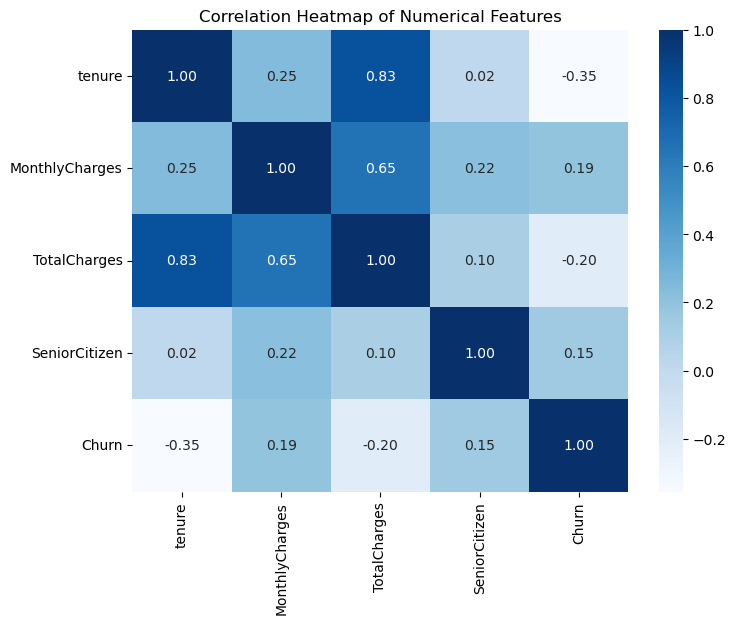

In [79]:
# Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']

# Correlation matrix
corr = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Numerical Features")

plt.savefig("../outputs/correlation_heatmap.png")

plt.show()

In [24]:
# Data preparation
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [25]:
# Drop unnecessary columns
df_model = df.drop(['customerID', 'tenure_group', 'RiskSegment'], axis=1)

In [26]:
# Encoding variables
df_encoded = pd.get_dummies(df_model, drop_first=True)

In [27]:
#Split Data

from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# Handle imbalance
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [29]:
# scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# Train Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [72]:
# KNN MODEL
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7185501066098081
KNN Confusion Matrix:
 [[772 261]
 [135 239]]
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.75      0.80      1033
           1       0.48      0.64      0.55       374

    accuracy                           0.72      1407
   macro avg       0.66      0.69      0.67      1407
weighted avg       0.75      0.72      0.73      1407



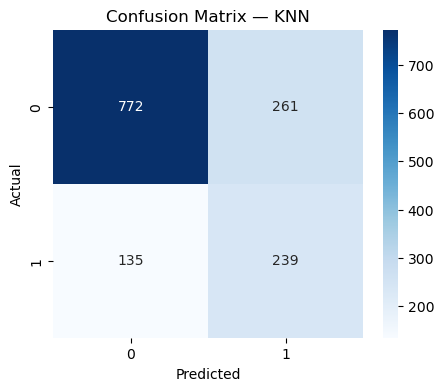

In [81]:
# Confusion Matrix Heatmap — KNN

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix — KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/cm_knn.png")

plt.show()

In [32]:
# predictions
y_pred = model.predict(X_test)


In [33]:
# probability (advanced)
y_prob = model.predict_proba(X_test)[:,1]


In [74]:
# Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("LogisticRegression Accuracy:", accuracy_score(y_test, y_pred))
print("LogisticRegression Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("LogisticRegression Classification Report:\n", classification_report(y_test, y_pred))

LogisticRegression Accuracy: 0.7704335465529495
LogisticRegression Confusion Matrix:
 [[847 186]
 [137 237]]
LogisticRegression Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



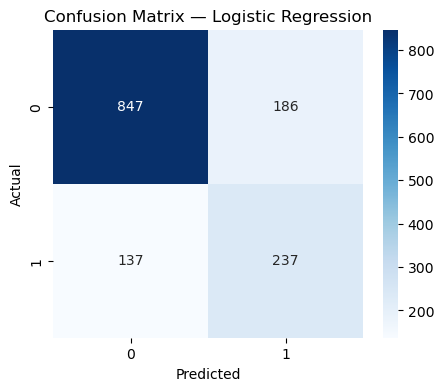

In [80]:
# Confusion Matrix Heatmap — Logistic Regression

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/cm_logistic.png")

plt.show()

In [ ]:
# Random Forest Moel

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:",confusion_matrix(y_test, y_pred_rf))
print("Random Forest Classification Report:",classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7512437810945274
Random Forest Confusion Matrix: [[776 257]
 [ 93 281]]
Random Forest Classification Report:               precision    recall  f1-score   support

           0       0.89      0.75      0.82      1033
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407



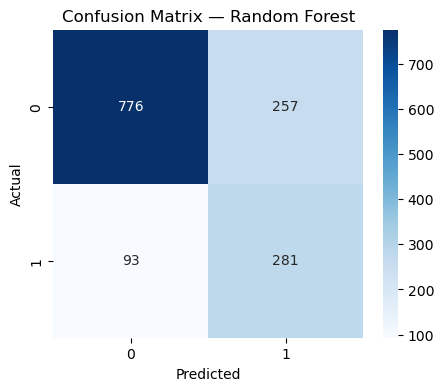

In [82]:
# Confusion Matrix Heatmap — Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/cm_rf.png")

plt.show()

In [65]:
# XGBOOST Model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [66]:
# Train
xgb_model.fit(X_train, y_train)

c:\Users\Aakanksha haravde\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:43:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [67]:
# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [70]:
# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7604832977967306
XGBoost Confusion Matrix:
 [[833 200]
 [137 237]]
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.76      0.77      1407



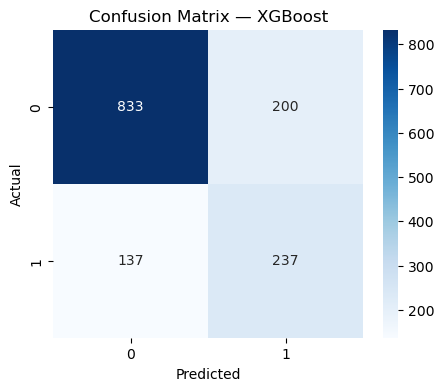

In [83]:
# Confusion Matrix Heatmap — XGBoost

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix — XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/cm_xgb.png")

plt.show()

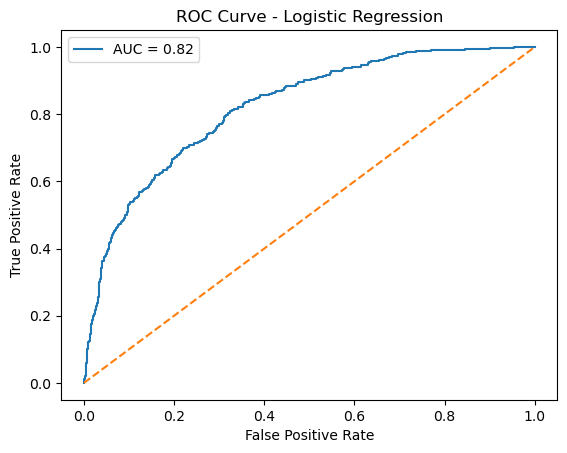

In [85]:
# ROC Curve for Logistic regression 

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("../outputs/roc_curve.png")
plt.show()

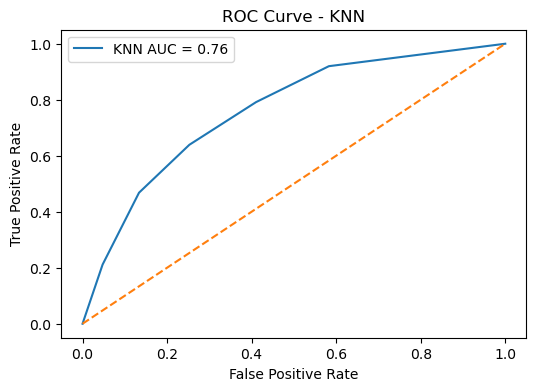

In [77]:
# ROC Curve for KNN

y_prob_knn = knn_model.predict_proba(X_test)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(6,4))
plt.plot(fpr_knn, tpr_knn, label=f"KNN AUC = {auc_knn:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.savefig("../outputs/roc_curve_knn.png")
plt.show()

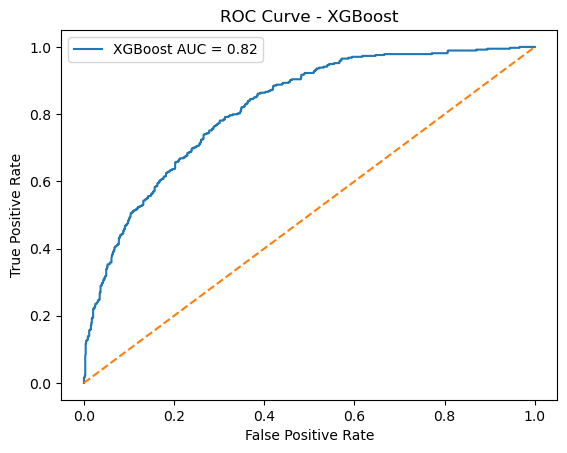

In [41]:
# ROC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {auc_xgb:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.savefig("../outputs/roc_curve_xgb.png")
plt.show()

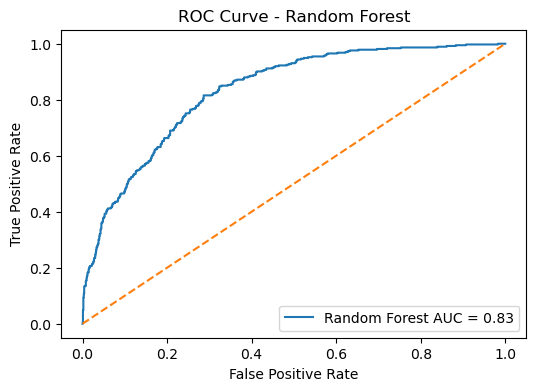

In [76]:
# ROC Curve for Random Forest

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.savefig("../outputs/roc_curve_rf.png")
plt.show()

In [42]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 4, 5]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


In [43]:
# Comparing Both LogisticRegression and XGBoost
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression: 0.7704335465529495
KNN: 0.7185501066098081
Random Forest: 0.7512437810945274
XGBoost: 0.7604832977967306


In [44]:
# Feature Importance

importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values(ascending=False)

print("Top Features Influencing Churn:")
print(importance.head(10))


Top Features Influencing Churn:
InternetService_Fiber optic       4.244992
PhoneService_Yes                  2.914299
MultipleLines_No phone service    1.635396
StreamingMovies_Yes               1.624296
StreamingTV_Yes                   1.578501
TotalCharges                      1.279671
MultipleLines_Yes                 0.927476
DeviceProtection_Yes              0.723990
OnlineBackup_Yes                  0.699845
PaymentMethod_Electronic check    0.576137
dtype: float64


In [45]:
# High Risk Customers

results = pd.DataFrame(X_test, columns=X.columns)

results['Actual'] = y_test.values
results['Predicted'] = y_pred_xgb
results['Churn_Probability'] = y_prob_xgb

In [46]:
# Top 10 high-risk customers
high_risk = results.sort_values(by='Churn_Probability', ascending=False)

print("Top 10 High Risk Customers:")
print(high_risk[['Churn_Probability']].head(10))

Top 10 High Risk Customers:
      Churn_Probability
168            0.966899
16             0.965762
857            0.962522
1053           0.962522
866            0.958907
351            0.957305
407            0.953471
822            0.952034
475            0.946349
1145           0.946312


In [47]:
# Save Model

import joblib
import os 

os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_model, "../models/churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [48]:
model = joblib.load("../models/churn_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

In [49]:
# Test prediction
from regex import T


sample = X_test[0:1]

prediction = model.predict(sample)
print(prediction)

[0]


In [50]:
print(pd.Series(y_pred).value_counts())

0    984
1    423
Name: count, dtype: int64


In [51]:
print(y_pred[:10])

[0 0 1 0 0 1 0 1 0 0]


In [52]:
print(model.predict_proba(X_test[0:1]))

[[0.9904488  0.00955122]]


In [53]:
import numpy as np

high_risk_index = np.argmax(y_prob)
print(model.predict(X_test[high_risk_index:high_risk_index+1]))

print(pd.Series(y_pred).value_counts())

[1]
0    984
1    423
Name: count, dtype: int64
